In [1]:
from google.colab import files



uploaded = files.upload()

Saving FISHMORPH_Family_Dataset.csv to FISHMORPH_Family_Dataset.csv


In [2]:
import pandas as pd

    df = pd.read_csv("FISHMORPH_Family_Dataset.csv")
df.head()

,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Family
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cyprinidae
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Cichlidae
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cyprinidae
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cyprinidae
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cyprinidae


In [3]:
print(df.shape)
df.info()
print(df.isnull().sum())
print("Duplicados:", df.duplicated().sum())
df.describe()

(8342, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Family  8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB
MBl       0
BEl       0
VEp       0
REs       0
OGp       0
RMl       0
BLs       0
PFv       0
PFs       0
CPt       0
Family    0
dtype: int64
Duplicados: 1


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt
count,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000,8342.000000
mean,22.004517,4.452438,0.549087,0.391665,0.381768,0.399786,0.571818,0.285316,0.189343,2.560795
std,33.612007,2.338235,0.094883,0.132814,0.194352,0.302658,0.117486,0.155629,0.056109,1.016659
min,1.200000,1.033084,0.159248,0.000000,0.000000,0.000000,0.224525,0.000000,0.000000,0.000000
25%,7.000000,3.139102,0.487993,0.293205,0.278014,0.257999,0.490052,0.193134,0.157972,1.999744
50%,12.600000,4.038851,0.546213,0.389429,0.406904,0.361436,0.564739,0.275039,0.183497,2.436329
75%,24.500000,5.002621,0.605125,0.486221,0.516001,0.490671,0.648039,0.368876,0.215031,2.919818
max,800.000000,43.728161,1.000000,1.026667,1.026316,7.060344,1.230105,0.857097,0.511113,15.452061


In [4]:
df['Family'].value_counts()


,count
Family,
Cyprinidae,1545
Cichlidae,1060
Characidae,732
Loricariidae,427
Percidae,190
...,...
Sillaginidae,1
Serrasalmidae,1
Bythitidae,1


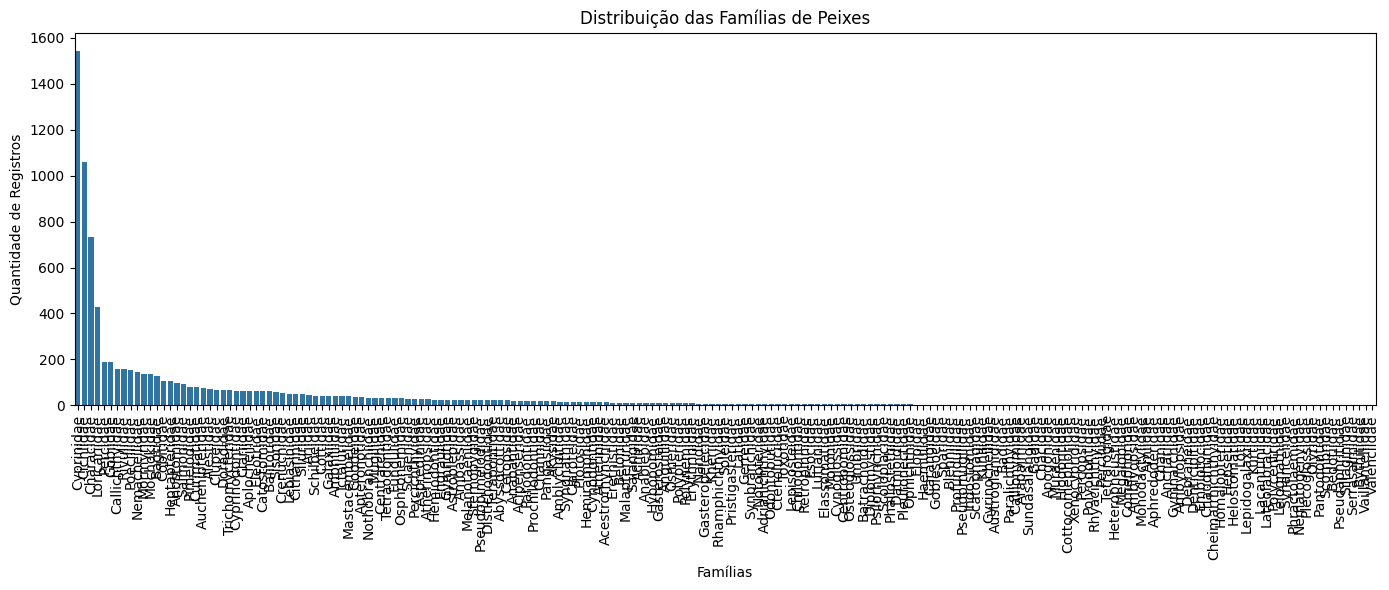

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='Family',
    order=df['Family'].value_counts().index
)

plt.title('Distribuição das Famílias de Peixes')
plt.xlabel('Famílias')
plt.ylabel('Quantidade de Registros')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [6]:
X = df.drop('Family', axis=1)
y = df['Family']

print("X:", X.shape)
print("y:", y.shape)

X: (8342, 10)
y: (8342,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

Treinamento: (6673, 10)
Teste: (1669, 10)


In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

modelo = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

parametros = {
    'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    modelo,
    parametros,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm', SVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 1, 10, 100],
                         'svm__gamma': [0.001, 0.01, 0.1, 1],
                         'svm__kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

In [11]:
print("Melhor modelo:")
print(grid.best_estimator_)
print("\nMelhores parâmetros:")
print(grid.best_params_)
print("\nAcurácia da validação cruzada:")
print(grid.best_score_)


Melhor modelo:
Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(C=10, gamma=0.1))])

Melhores parâmetros:
{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}

Acurácia da validação cruzada:
0.619160441568854


In [13]:
melhor_modelo = grid.best_estimator_

X_teste_original = df.drop('Family', axis=1).loc[y_test.index]

y_pred = melhor_modelo.predict(X_teste_original)


In [14]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acuracia:.4f}")
print(f"Acurácia em porcentagem: {acuracia * 100:.2f}%")

Acurácia do modelo: 0.8197
Acurácia em porcentagem: 81.97%


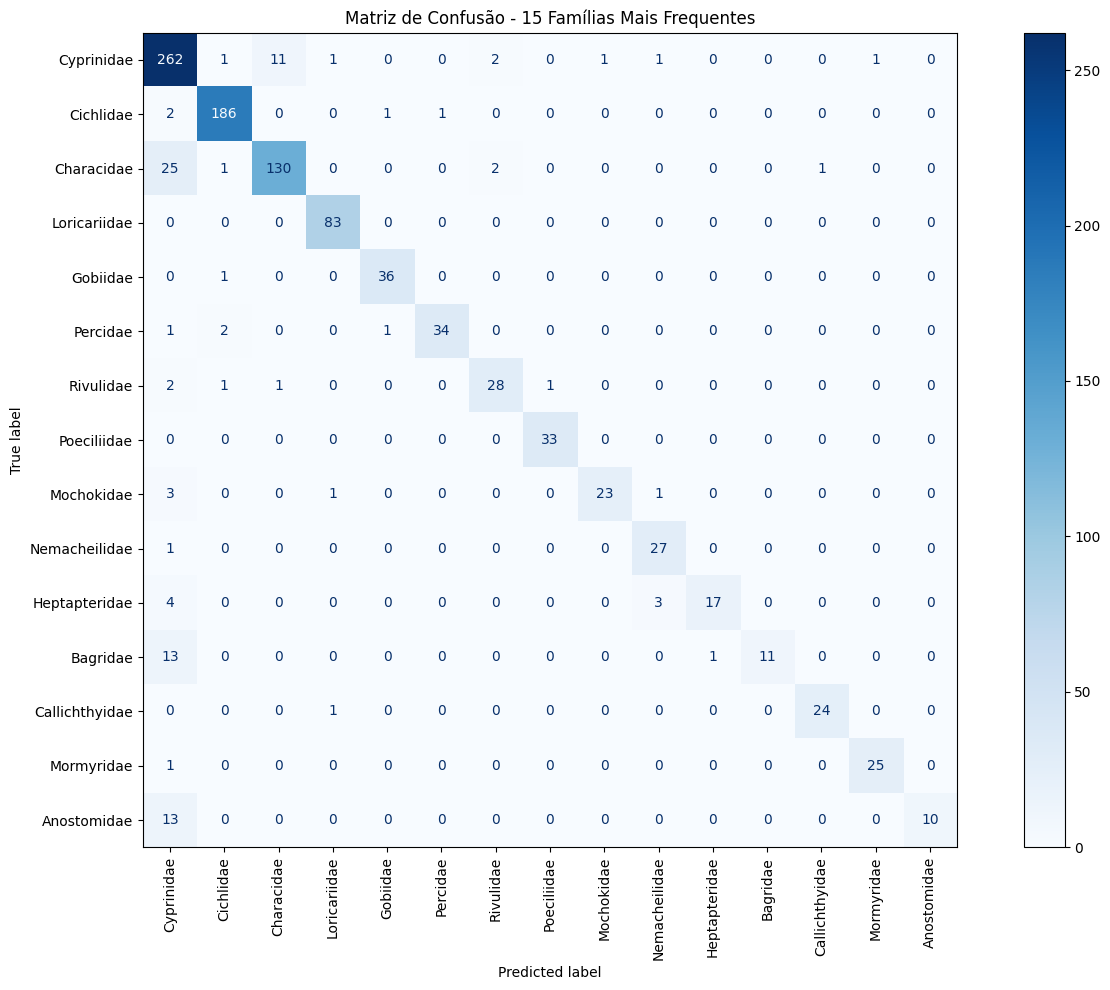

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

top_familias = y_test.value_counts().head(15).index
fig, ax = plt.subplots(figsize=(14, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=top_familias,
    cmap='Blues',
    xticks_rotation=90,
    ax=ax
)
plt.title("Matriz de Confusão - 15 Famílias Mais Frequentes")
plt.tight_layout()
plt.show()

In [17]:
print("Melhores parâmetros:", grid.best_params_)
print(f"Acurácia Cross-Validation: {grid.best_score_ * 100:.2f}%")
print(f"Acurácia no teste: {acuracia * 100:.2f}%")

Melhores parâmetros: {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Acurácia Cross-Validation: 61.92%
Acurácia no teste: 81.97%
